<a href="https://colab.research.google.com/github/ewarren38/HW6_WarrenE/blob/main/HW6_WarrenE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 6**
**Author:** Eleanor Warren

**Course:** ST554-601

**Purpose:** Complete HW 6

**Date:** 3.10.26



##**Part 1 | Querying Databases**

First I'm estalblishing a connection to the Lahman baseball database, and then returning a pandas dataframe, `schema_df`, with all the tables in the database.

In [212]:
import pandas as pd
import sqlite3
con = sqlite3.connect("/content/lahman_1871-2022.sqlite")
get_schema = '''
   SELECT *
   FROM sqlite_schema
   WHERE type = 'table';
   '''
schema_df = pd.read_sql(get_schema, con)
schema_df

# The simple querying structure:
# pd.read_sql("SELECT ... FROM ... WHERE...;", con) using con from above.

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


2. Construct a table of hall of fame pitchers (any hall of famer that pitched) with their `playerID` and sum for `GS, G, W, L, IPOuts, CG, SHO, SV`.

We need to merge together information from the Pitching and the HallOfFame tables.

In [213]:
pitch_stats = pd.read_sql("""
  SELECT DISTINCT p.playerID, sum(p.GS), sum(p.G), sum(p.W), sum(p.L), sum(p.IPOuts), sum(p.CG), sum(p.SHO), sum(p.SV)
  FROM Pitching AS p
  INNER join HallOfFame AS h ON h.playerID = p.playerID
  WHERE inducted = 'Y'
  GROUP BY p.playerID
  ORDER BY p.playerID;
  """, con)

# Inspect the first few rows of the table
pitch_stats.head()

,playerID,sum(p.GS),sum(p.G),sum(p.W),sum(p.L),sum(p.IPOuts),sum(p.CG),sum(p.SHO),sum(p.SV)
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0


Next, we want to find some batting stats for these Hall of Fame pitchers. The first step I'll take is to just get the total batting statistics for all pitchers.

In [214]:
bat_stats = pd.read_sql("""
  SELECT DISTINCT b.playerID, sum(b.AB), sum(b.R), sum(b.H), sum(b.HR), sum(b.RBI), sum(b.BB), sum(b.SO)
  FROM Batting AS b
  INNER join Pitching AS p ON b.playerID = p.playerID
  GROUP BY p.playerID
  ORDER BY p.playerID;
  """, con)

# Use sum() and GROUP BY to get the total value for each statistic
bat_stats.head()

,playerID,sum(b.AB),sum(b.R),sum(b.H),sum(b.HR),sum(b.RBI),sum(b.BB),sum(b.SO)
0,aardsda01,36,0,0,0,0.0,0,18.0
1,aasedo01,65,0,0,0,0.0,0,39.0
2,abadfe01,99,0,11,0,0.0,0,55.0
3,abbeybe01,1350,126,228,0,102.0,126,324.0
4,abbeych01,1756,307,493,19,280.0,167,122.0


Now, I'll do an inner merge of my new table that has all pitchers and their batting stats with the Hall of Fame table, so that I can bring the batting information in for just HoF pitchers.

In [215]:
# Inner join makes sure only the pitchers that are found in the HOF table stay
HOF_PB_stats = pd.merge(
    left = pitch_stats,
    right = bat_stats,
    how = "inner",
    on = "playerID"
)

HOF_PB_stats

,playerID,sum(p.GS),sum(p.G),sum(p.W),sum(p.L),sum(p.IPOuts),sum(p.CG),sum(p.SHO),sum(p.SV),sum(b.AB),sum(b.R),sum(b.H),sum(b.HR),sum(b.RBI),sum(b.BB),sum(b.SO)
0,alexape01,599,696,373,208,15570,437,90,32,38010,3234,7938,231,3423.0,1617,5796.0
1,ansonca01,0,3,0,1,12,0,0,1,20562,3998,6870,194,4150.0,1968,660.0
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581.0,616,526.0
3,bendech01,334,459,212,127,9051,255,40,34,18352,1632,3888,96,1856.0,1200,2288.0
4,blylebe01,685,692,287,250,14910,242,60,0,10824,456,1416,0,600.0,120,4632.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11,19409,1391,3224,13,1092.0,1053,2587.0
104,wrighge01,0,3,0,1,15,0,0,0,5746,1330,1732,22,652.0,136,238.0
105,wrighha01,8,36,4,4,301,0,0,14,3252,732,896,16,452.0,148,56.0
106,wynnea01,612,691,300,244,13692,290,49,15,39192,3128,8395,391,3979.0,3243,7590.0


##**Part 2 | Messing with Classes**

First, I bring in the code from last week that creates simulated data and charts a histogram for us.

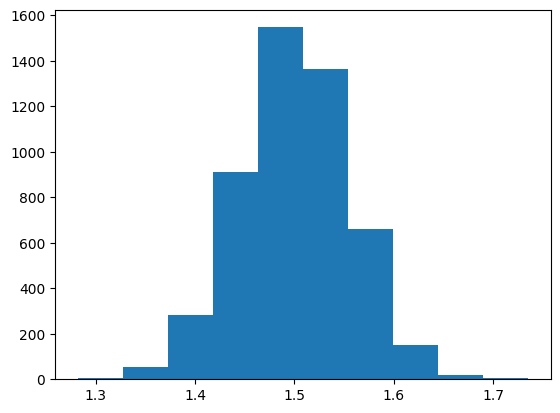

In [216]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)

#prepare for the LR fit
reg = linear_model.LinearRegression()
#Create a reg object

#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))
for i in range(5000):
  #create the 'responses' modeled from the line plus a random deviation
  y = beta_0 + beta_1*x + rng.standard_normal(n)
  #find the least squares solutions and store them
  fit = reg.fit(x.reshape(-1, 1), y)
  beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

Code that estimates the probability that an observed beta_1 is greater than a given value.

In [217]:
#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

np.float64(0.0038)

We'll turn this into a class using many steps.

1. Initialize some attributes of our SLR (beta, seed, number of data points in each simulated sample)
2. Create a method that generates one random data set
3. Create a method that fits the slope from that data set
4. Create a method that repeats those two steps for a given number of simulations and saves all the fitted slopes.
5. Create a method that plots a histogram for all those fitted slopes.
6. Calculate the probability that we observe a fitted slope greater/less than a given value based on the sampling distribution of our slopes.

In [218]:
class SLR_slope_simulator:
  #import some modules needed
  import numpy as np
  from numpy.random import default_rng
  from sklearn import linear_model
  slopes = []

  def __init__(self, beta_0, beta_1, x, sigma, seed):
    """
    Initiator Attributes
    """
    self.beta_0 = 7
    self.beta_1 = 1.5
    self.rng = default_rng(32)
    self.beta_0 = 7
    self.beta_1 = 1.5
    self.x = list(np.linspace(start = 0, stop = 10, num = 11))*3
    self.n = len(self.x)

  def generate_data(self):
    """
    Method to generate one random data set
    """
    import pandas as pd
    x_list = self.x
    y_list = []
    #create the 'responses' modeled from the line plus a random deviation
    for i in range(0,self.n):
      y = beta_0 + beta_1*x_list[i] + rng.standard_normal(1)
      y_list.append(y)
      sim_data = pd.DataFrame(zip(x_list, y_list), columns = ("x", "y"))
    return sim_data

  def fit_slope(self, sim_data):
    """
    Method to fit the slope of one data set using an SLR
    """
    reg.fit(sim_data['x'].values.reshape(-1, 1), sim_data['y']) # fit the sample data
    return reg.coef_

  def run_simulations(self, simulations):
    """
    Method to run a given number of simulations to generate random data
    based on an SLR, then fit their slopes and save them
    """
    for i in range(simulations+1):
        x = SLR_slope_simulator(7, 1.5, list(np.linspace(start = 0, stop = 10, num = 11))*3, 1, 32)
        data = x.generate_data()
        slope = x.fit_slope(data)
        SLR_slope_simulator.slopes.append(slope)
    return SLR_slope_simulator.slopes[0:11]

  def plot_sampling_distribution(self):
    """
    Method to create a histogram plot illustrating the sampling
    distribution of beta_1
    """
    import pandas as pd
    if len(SLR_slope_simulator.slopes) > 0:
      DF = pd.DataFrame(SLR_slope_simulator.slopes)
      DF.plot.hist()
    else:
      print("run_simulations() must be called first")

  def find_prob(self, value, sided):
    """
    Method to calculate the probability of observing a fitted slope
    larger/smaller than a given value
    """
    slopes = np.array(SLR_slope_simulator.slopes)
    if len(SLR_slope_simulator.slopes) > 0:
      if sided == "above":
        count_above = np.sum(slopes > value)
        prob = count_above / len(slopes)
      elif sided == "below":
        count_below = np.sum(slopes < value)
        prob = count_below / len(slopes)
      elif sided == "two-sided":
        if value > slopes.median():
          count_above = np.sum(slopes > value)
          prob = 2*(count_above / len(slopes))
        else:
          count_below = np.sum(slopes < value)
          prob = 2*(count_below / len(slopes))
    return prob

Here is where I tested out my methods as I worked:

np.float64(1.0)

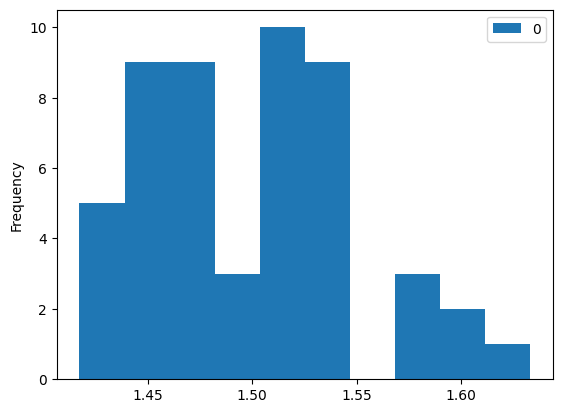

In [219]:
x = SLR_slope_simulator(7, 1.5, list(np.linspace(start = 0, stop = 10, num = 11))*3, 1, 32)
data = x.generate_data()
x.fit_slope(data)
x.run_simulations(50)
x.plot_sampling_distribution()
x.find_prob(1.4, "above")

Formally create a new instance using our class object, this time with different attributes than the default ones in our class definition.

In [220]:
# Create a new instance
instance = SLR_slope_simulator(12, 2, list(np.linspace(start = 0, stop = 10, num = 11))*3, 1, 10)

Run the simulation 10000 times.

In [221]:
instance.run_simulations(10000)

[array([1.53113551]),
 array([1.43131772]),
 array([1.52536053]),
 array([1.4369629]),
 array([1.44597261]),
 array([1.41724387]),
 array([1.51911545]),
 array([1.48504986]),
 array([1.46438513]),
 array([1.52746243]),
 array([1.47762911])]

Plot the histogram for our 10000 fitted slopes from the 10000 simulated samples.

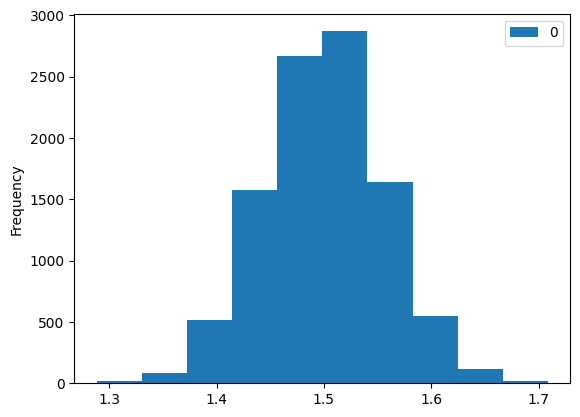

In [222]:
instance.plot_sampling_distribution()

Calculate the probability that we observe a fitted slope greater than 2.1. It yields a probability of 0.

In [223]:
x.find_prob(2.1, "above")

np.float64(0.0)

Only print off the first few entries of our attribute that contains all of our fitted slopes, since we don't want to see all 10000.

In [224]:
x.slopes[0:11]

[array([1.53113551]),
 array([1.43131772]),
 array([1.52536053]),
 array([1.4369629]),
 array([1.44597261]),
 array([1.41724387]),
 array([1.51911545]),
 array([1.48504986]),
 array([1.46438513]),
 array([1.52746243]),
 array([1.47762911])]